In [5]:
import pandas as pd
df = pd.read_csv("weather_data.csv")
df

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/4/2017,NaN,9.0,Sunny
2,1/5/2017,28.0,NaN,Snow
3,1/6/2017,NaN,7.0,NaN
4,1/7/2017,32.0,NaN,Rain
5,1/8/2017,NaN,NaN,Sunny
6,1/9/2017,NaN,NaN,NaN
7,1/10/2017,34.0,8.0,Cloudy
8,1/11/2017,40.0,12.0,Sunny


<Axes: >

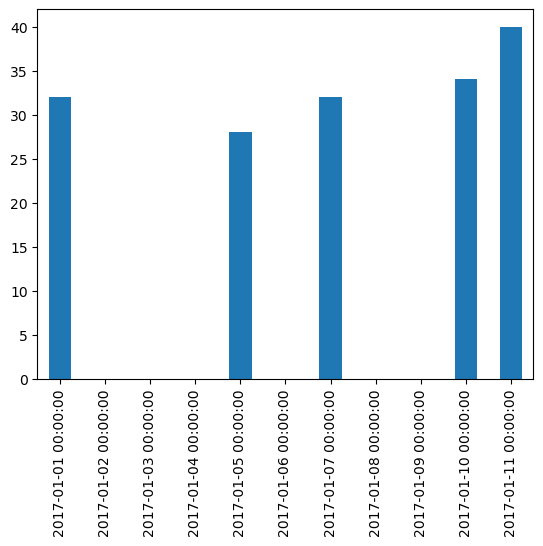

In [67]:
%matplotlib inline
df.temperature.plot.bar()

# IMPORTANT:
# %matplotlib inline -> Graph notebook ke andar dikhata hai.
# .plot.bar() -> Bar Chart banata hai.
# X-axis -> Index
# Y-axis -> Selected column ki values
# Pandas plotting ke liye internally Matplotlib use karta hai.

In [6]:
df = pd.read_csv("weather_data.csv")
type(df.day[0])


str

In [4]:
import pandas as pd
df = pd.read_csv("weather_data.csv", parse_dates=["day"]) # Yha pr parse_dates str ko date me change kr rha h jb uper wale me check kroge to wo str hi aata h
df

,day,temperature,windspeed,event
0,2017-01-01,32.0,6.0,Rain
1,2017-01-04,NaN,9.0,Sunny
2,2017-01-05,28.0,NaN,Snow
3,2017-01-06,NaN,7.0,NaN
4,2017-01-07,32.0,NaN,Rain
5,2017-01-08,NaN,NaN,Sunny
6,2017-01-09,NaN,NaN,NaN
7,2017-01-10,34.0,8.0,Cloudy
8,2017-01-11,40.0,12.0,Sunny


In [7]:
df = pd.read_csv("weather_data.csv", parse_dates=["day"])
type(df.day[0])

pandas._libs.tslibs.timestamps.Timestamp

In [20]:
df = pd.read_csv("weather_data.csv", parse_dates=["day"])
df.set_index('day', inplace=True)
df

# IMPORTANT:
# parse_dates=["day"] ka use 'day' column ko string se datetime format me convert karne ke liye hota hai.
# Datetime format hone se date ke basis par filtering, sorting aur time-series analysis aasaan ho jata hai.
# set_index('day') ka use 'day' column ko DataFrame ka index banane ke liye hota hai.
# inplace=True ka matlab original DataFrame ko hi update karna, naya DataFrame create nahi hota.
# Date ko index banane ke baad 'day' normal column nahi rehta, isliye df['day'] error de sakta hai.
# Date ko access karne ke liye df.loc['2017-01-03'] ya df.loc['2017'] use kiya jata hai.
# Agar 'day' ko wapas normal column banana ho, to df.reset_index() use karte hain.
# Time-series data (Weather, Stock Market, Sales, etc.) me datetime index banana best practice mana jata hai.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [17]:
new_df = df.fillna(0)
new_df

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,0.0,9.0,Sunny
2017-01-05,28.0,0.0,Snow
2017-01-06,0.0,7.0,0
2017-01-07,32.0,0.0,Rain
2017-01-08,0.0,0.0,Sunny
2017-01-09,0.0,0.0,0
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [21]:
new_df = df.fillna({
    'temperature': 0,
    'windspeed': 0,
    'event': 'no event'
})
new_df

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,0.0,9.0,Sunny
2017-01-05,28.0,0.0,Snow
2017-01-06,0.0,7.0,no event
2017-01-07,32.0,0.0,Rain
2017-01-08,0.0,0.0,Sunny
2017-01-09,0.0,0.0,no event
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [25]:
new_df = df.ffill()
new_df


# IMPORTANT:
# ffill() ka matlab Forward Fill hota hai.
# Ye NaN value ko uske upar wali valid value se replace karta hai.
# Agar pehli row me NaN ho, to wo fill nahi hoti kyunki uske upar koi value nahi hoti.
# Latest Pandas versions me fillna(method='ffill') deprecated hai.
# Isliye df.ffill() use karna best practice hai.
# Time-series aur sequential data me ffill() bahut commonly use hota hai.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,32.0,9.0,Sunny
2017-01-05,28.0,9.0,Snow
2017-01-06,28.0,7.0,Snow
2017-01-07,32.0,7.0,Rain
2017-01-08,32.0,7.0,Sunny
2017-01-09,32.0,7.0,Sunny
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [29]:
new_df = df.bfill()
new_df

# IMPORTANT:
# bfill() ka matlab Backward Fill hota hai.
# Ye NaN value ko uske niche wali valid value se replace karta hai.
# Agar last row me NaN ho, to wo fill nahi hoti kyunki uske niche koi value nahi hoti.
# Latest Pandas versions me fillna(method='bfill') deprecated hai.
# Isliye df.bfill() use karna best practice hai.
# Time-series aur sequential data me bfill() bhi commonly use hota hai.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,28.0,9.0,Sunny
2017-01-05,28.0,7.0,Snow
2017-01-06,32.0,7.0,Rain
2017-01-07,32.0,8.0,Rain
2017-01-08,34.0,8.0,Sunny
2017-01-09,34.0,8.0,Cloudy
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [38]:
new_df = df.bfill(axis=1)
new_df

# IMPORTANT:
# bfill(axis=1) ka matlab Backward Fill across columns hota hai.
# axis=1 ka matlab rows ke andar left-right direction me operation hoga.
# Agar kisi cell me NaN hai, to uske RIGHT (bagal wale) column ki value se fill kiya jayega.
# Original DataFrame change nahi hoga, kyunki result new_df me store ho raha hai.
# new_df likhne se updated DataFrame display ho jayega.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,9.0,9.0,Sunny
2017-01-05,28.0,Snow,Snow
2017-01-06,7.0,7.0,NaN
2017-01-07,32.0,Rain,Rain
2017-01-08,Sunny,Sunny,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [43]:
new_df = df.ffill(limit=1)
new_df

# IMPORTANT:
# ffill() ka matlab Forward Fill hota hai.
# Ye NaN values ko upar wali valid value se fill karta hai.
# limit=1 ka matlab ek hi consecutive NaN ko fill karega.
# Agar 2 ya usse zyada consecutive NaN honge, to sirf pehla NaN fill hoga.
# Original DataFrame change nahi hoga, kyunki result new_df me store ho raha hai.
# new_df likhne se updated DataFrame display ho jayega.


,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,32.0,9.0,Sunny
2017-01-05,28.0,9.0,Snow
2017-01-06,28.0,7.0,Snow
2017-01-07,32.0,7.0,Rain
2017-01-08,32.0,NaN,Sunny
2017-01-09,NaN,NaN,Sunny
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [48]:
new_df = df.interpolate()
new_df

# IMPORTANT:
# interpolate() ka use missing (NaN) values ko estimate (calculate) karke fill karne ke liye hota hai.
# Ye previous aur next valid values ke basis par missing value nikalta hai.
# By default ye Linear Interpolation use karta hai.
# Ye mainly numeric columns par kaam karta hai.
# Time-series, Weather, Sales aur Sensor data me bahut use hota hai.
# Original DataFrame change nahi hota, jab tak inplace=True use na karein ya result kisi variable me store na karein.


C:\Users\mdnis\AppData\Local\Temp\ipykernel_18600\2871701758.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  new_df = df.interpolate()


,temperature,windspeed,event
day,,,
2017-01-01,32.000000,6.00,Rain
2017-01-04,30.000000,9.00,Sunny
2017-01-05,28.000000,8.00,Snow
2017-01-06,30.000000,7.00,NaN
2017-01-07,32.000000,7.25,Rain
2017-01-08,32.666667,7.50,Sunny
2017-01-09,33.333333,7.75,NaN
2017-01-10,34.000000,8.00,Cloudy
2017-01-11,40.000000,12.00,Sunny


In [51]:
new_df = df.interpolate(method="time")
new_df

# method="time" sirf DatetimeIndex ke saath kaam karta hai.
# Time-series data me iska use hota hai.
# Date ke actual gap ko consider karke values calculate karta hai.
# Agar DatetimeIndex nahi hoga to error aayega.

C:\Users\mdnis\AppData\Local\Temp\ipykernel_18600\336925.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  new_df = df.interpolate(method="time")


,temperature,windspeed,event
day,,,
2017-01-01,32.000000,6.00,Rain
2017-01-04,29.000000,9.00,Sunny
2017-01-05,28.000000,8.00,Snow
2017-01-06,30.000000,7.00,NaN
2017-01-07,32.000000,7.25,Rain
2017-01-08,32.666667,7.50,Sunny
2017-01-09,33.333333,7.75,NaN
2017-01-10,34.000000,8.00,Cloudy
2017-01-11,40.000000,12.00,Sunny


In [53]:
new_df = df.dropna()
new_df

# dropna() = NaN values wali rows/columns ko remove karta hai.
# By default axis=0 hota hai (rows delete hoti hain).
# By default how='any' hota hai (ek bhi NaN ho to row delete).
# inplace=True se original DataFrame update ho jata hai.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [56]:
new_df = df.dropna(how="all")
new_df

# IMPORTANT:
# dropna(how="all") sirf un rows ko delete karta hai jisme sabhi values NaN hoti hain.
# Agar row me ek bhi valid (non-NaN) value hai, to wo row delete nahi hogi.
# Original DataFrame change nahi hota, kyunki result new_df me store ho raha hai.
# Completely empty rows ko remove karne ke liye how="all" use kiya jata hai.

# dropna()               -> Default how="any"
# dropna(how="any")      -> Ek bhi NaN ho to row delete.
# dropna(how="all")      -> Sirf completely empty row delete.

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [58]:
new_df = df.dropna(how="any")
new_df

,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [64]:
new_df = df.dropna(thresh=2)
new_df

#| Parameter   | Meaning                                       |
#| ----------- | --------------------------------------------- |
#| `how="any"` | Ek bhi NaN ho to row delete.                  |
#| `how="all"` | Sirf sab values NaN hon to row delete.        |
#| `thresh=1`  | Kam se kam 1 valid value honi chahiye.        |
#| `thresh=2`  | Kam se kam 2 valid values honi chahiye.       |
#| `thresh=n`  | Kam se kam **n non-NaN values** honi chahiye. |



,temperature,windspeed,event
day,,,
2017-01-01,32.0,6.0,Rain
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-07,32.0,NaN,Rain
2017-01-10,34.0,8.0,Cloudy
2017-01-11,40.0,12.0,Sunny


In [68]:
dt = pd.date_range("01-01-2017","01-11-2017")
idx = pd.DatetimeIndex(dt)
df = df.reindex(idx)
df

,temperature,windspeed,event
2017-01-01,32.0,6.0,Rain
2017-01-02,NaN,NaN,NaN
2017-01-03,NaN,NaN,NaN
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy


,temperature,windspeed,event
2017-01-01,32.0,6.0,Rain
2017-01-02,NaN,NaN,NaN
2017-01-03,NaN,NaN,NaN
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy


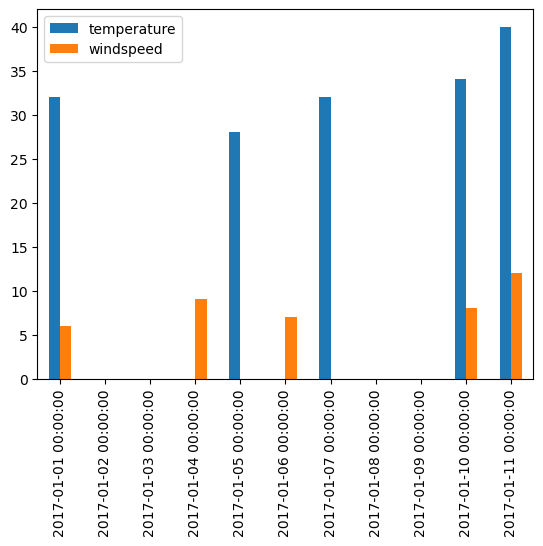

In [70]:
df.plot.bar() # Bar Chart
df

<Axes: >

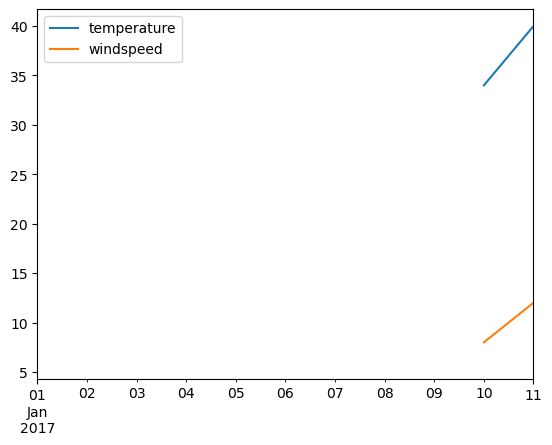

In [73]:
df.plot.line() # Line Chart

,temperature,windspeed,event
2017-01-01,32.0,6.0,Rain
2017-01-02,NaN,NaN,NaN
2017-01-03,NaN,NaN,NaN
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy


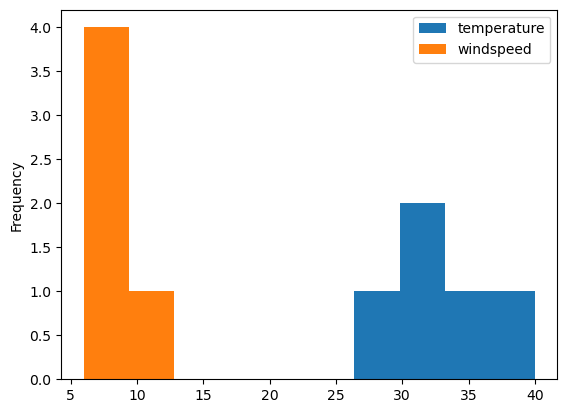

In [75]:
df.plot.hist()
df

<Axes: xlabel='temperature', ylabel='windspeed'>

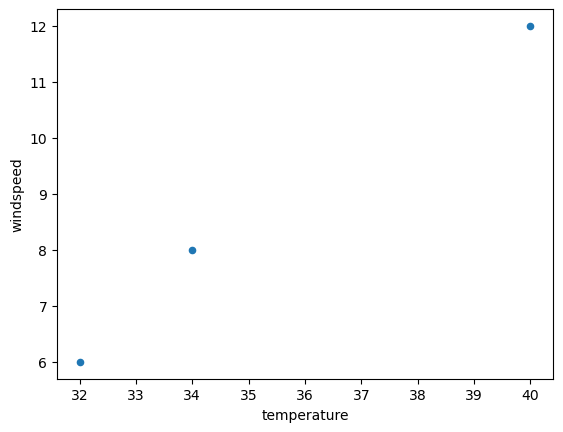

In [86]:
df.plot.scatter(x='temperature', y='windspeed')  # Scatter Plot

<Axes: >

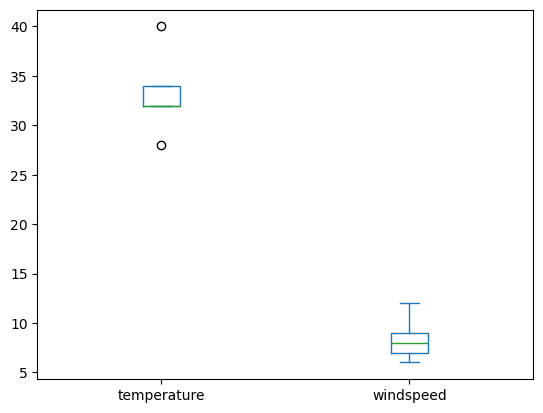

In [82]:
df.plot.box()

<Axes: ylabel='temperature'>

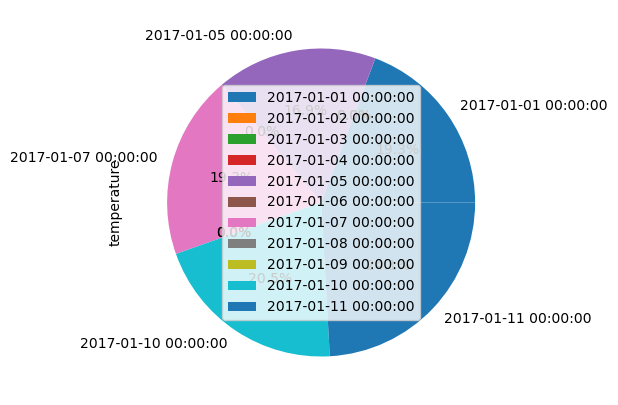

In [92]:
df.plot.pie(y='temperature', figsize=(5,5), autopct='%1.1f%%')

# IMPORTANT:
# Pie Chart ek numeric column ka proportion dikhata hai.
# y me hamesha DataFrame ka existing numeric column dena hota hai.
# Agar column exist nahi karega to KeyError aayega.
# Labels optional hote hain aur chart ko readable banate hain.

In [93]:
df.head()

# IMPORTANT:
# Graph banate waqt hamesha DataFrame ke actual column names use karein.
# Agar galat column name denge to KeyError aayega.
# Scatter Plot ke liye x aur y dono numeric columns hone chahiye.
# Pie Chart ke liye y me numeric column dena hota hai.
# NaN values hone par kuch graphs incomplete ya blank dikh sakte hain.

,temperature,windspeed,event
2017-01-01,32.0,6.0,Rain
2017-01-02,NaN,NaN,NaN
2017-01-03,NaN,NaN,NaN
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow


<Axes: ylabel='Frequency'>

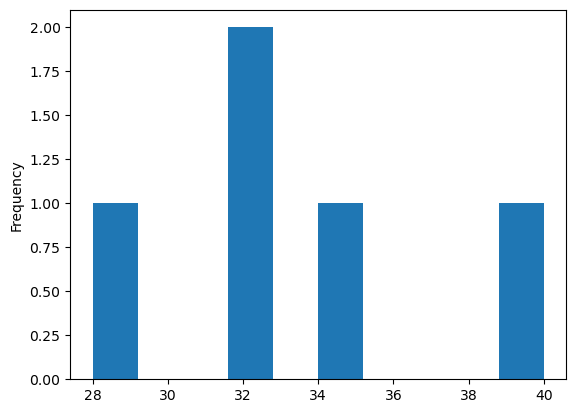

In [95]:
df.temperature.plot.hist()

<Axes: >

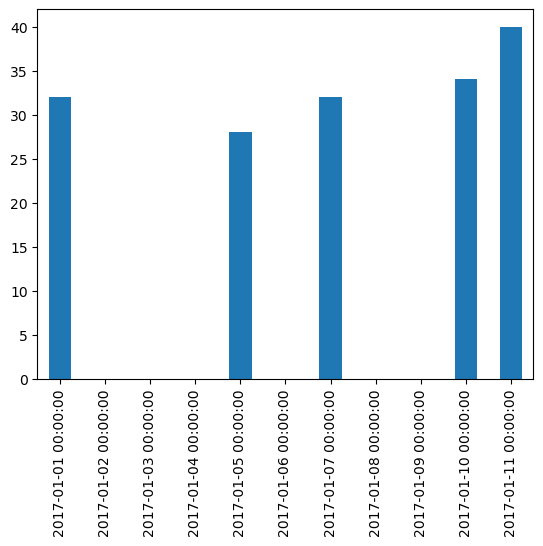

In [97]:
df.temperature.plot.bar()

<Axes: >

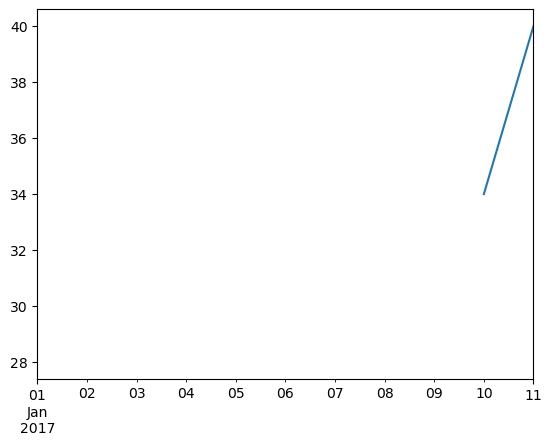

In [99]:
df.temperature.plot()

,temperature,windspeed,event
2017-01-01,32.0,6.0,Rain
2017-01-02,NaN,NaN,NaN
2017-01-03,NaN,NaN,NaN
2017-01-04,NaN,9.0,Sunny
2017-01-05,28.0,NaN,Snow
2017-01-06,NaN,7.0,NaN
2017-01-07,32.0,NaN,Rain
2017-01-08,NaN,NaN,Sunny
2017-01-09,NaN,NaN,NaN
2017-01-10,34.0,8.0,Cloudy


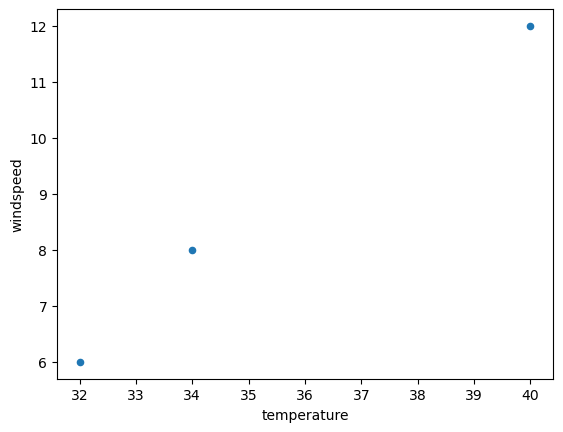

In [101]:
df.dropna().plot.scatter(x='temperature', y='windspeed')
df

# IMPORTANT:
# dropna() pehle un rows ko remove karta hai jisme NaN values hoti hain.
# Scatter Plot ke liye x aur y me valid numeric data hona chahiye.
# x='temperature' X-axis par temperature values dikhata hai.
# y='windspeed' Y-axis par windspeed values dikhata hai.
# Scatter Plot do numeric variables ke beech relationship ko dikhata hai.
# Original DataFrame change nahi hota, kyunki dropna() temporary DataFrame return karta hai.

# Handling Missing Data Documentation

Missing Data ko handle karne ke liye Pandas me mainly 3 methods use hote hain:

1. `fillna()`
2. `dropna()`
3. `interpolate()`

---

# `fillna()`

## Purpose

`fillna()` Missing Values (`NaN`) ko kisi specified value ya method se fill karta hai.

---

## Syntax

```python
DataFrame.fillna(
    value=None,
    method=None,
    axis=None,
    inplace=False,
    limit=None
)
```

---

## Parameters

### `value`

NaN ko kis value se replace karna hai.

```python
df.fillna(0)
```

---

### `method`

Previous ya Next value se fill karta hai.

```python
method="ffill"
method="bfill"
```

---

### `axis`

Direction specify karta hai.

```python
axis=0
axis=1
```

---

### `limit`

Maximum kitni consecutive NaN values fill hongi.

```python
limit=1
```

---

### `inplace`

Original DataFrame update kare ya nahi.

```python
inplace=True
```

---

## Examples

```python
df.fillna(0)

df.fillna(method="ffill")

df.fillna(method="bfill")

df.fillna(0, inplace=True)

df.fillna(method="ffill", limit=1)
```

---

# `dropna()`

## Purpose

`dropna()` Missing Values (`NaN`) wali rows ya columns ko remove karta hai.

---

## Syntax

```python
DataFrame.dropna(
    axis=0,
    how="any",
    thresh=None,
    subset=None,
    inplace=False
)
```

---

## Parameters

### `axis`

```python
axis=0    # Rows
axis=1    # Columns
```

---

### `how`

```python
how="any"
how="all"
```

- `any` → Agar ek bhi NaN ho to remove.
- `all` → Jab sabhi values NaN hon tab remove.

---

### `thresh`

Minimum non-null values honi chahiye.

```python
thresh=2
```

---

### `subset`

Sirf specified columns check karega.

```python
subset=["temperature"]
```

---

### `inplace`

Original DataFrame update karega.

```python
inplace=True
```

---

## Examples

```python
df.dropna()

df.dropna(how="all")

df.dropna(thresh=2)

df.dropna(axis=1)

df.dropna(subset=["temperature"])
```

---

# `interpolate()`

## Purpose

`interpolate()` Missing Values ko surrounding values ke basis par estimate (interpolate) karke fill karta hai.

---

## Syntax

```python
DataFrame.interpolate(
    method="linear",
    axis=0,
    limit=None,
    inplace=False
)
```

---

## Parameters

### `method`

Interpolation ka method.

```python
method="linear"

method="time"

method="index"

method="nearest"
```

---

### `axis`

```python
axis=0
axis=1
```

---

### `limit`

Maximum kitni NaN values fill hongi.

```python
limit=2
```

---

### `inplace`

Original DataFrame update karega.

```python
inplace=True
```

---

## Examples

```python
df.interpolate()

df.interpolate(method="time")

df.interpolate(method="linear")

df.interpolate(limit=1)
```

---

# Interview Questions & Answers

### Q1. `fillna()` kya karta hai?

**Answer:**  
Missing Values (`NaN`) ko kisi value ya method se fill karta hai.

---

### Q2. `dropna()` kya karta hai?

**Answer:**  
Missing Values wali rows ya columns remove karta hai.

---

### Q3. `interpolate()` kya karta hai?

**Answer:**  
Missing Values ko surrounding values ke basis par estimate karke fill karta hai.

---

### Q4. `ffill` kya hota hai?

**Answer:**  
Previous (upar wali) value se NaN fill karta hai.

---

### Q5. `bfill` kya hota hai?

**Answer:**  
Next (neeche wali) value se NaN fill karta hai.

---

### Q6. `how="all"` aur `how="any"` me difference?

| `how="any"` | `how="all"` |
|--------------|-------------|
| Ek bhi NaN ho to row/column remove | Sabhi values NaN hon tab remove |

---

### Q7. `thresh=2` kya karta hai?

**Answer:**  
Row/Column me kam se kam **2 non-null values** honi chahiye, warna remove ho jayegi.

---

### Q8. `fillna()` aur `interpolate()` me difference?

| `fillna()` | `interpolate()` |
|-------------|-----------------|
| Fixed value se fill karta hai | Estimated value se fill karta hai |
| Manual filling | Automatic estimation |

---

### Q9. `replace()` aur `fillna()` me difference?

| `replace()` | `fillna()` |
|--------------|------------|
| Kisi bhi value ko replace karta hai | Sirf NaN ko fill karta hai |

---

# Interview Important Points

- `fillna()`, `dropna()` aur `interpolate()` **DataFrame Methods** hain, isliye `df.fillna()`, `df.dropna()`, `df.interpolate()` likhte hain.
- `fillna()` Missing Values ko fill karta hai.
- `ffill` Previous (upar wali) value use karta hai.
- `bfill` Next (neeche wali) value use karta hai.
- `dropna()` Missing Values wali rows/columns remove karta hai.
- `how="any"` → Ek bhi NaN ho to remove.
- `how="all"` → Sabhi values NaN hon tab remove.
- `thresh` minimum non-null values specify karta hai.
- `interpolate()` estimated values se NaN fill karta hai.
- `method="time"` time-series data ke liye use hota hai.
- `limit` maximum consecutive NaN values fill karta hai.
- `inplace=True` original DataFrame modify karta hai.
- Teeno methods ka return type **DataFrame** hota hai (jab `inplace=False` ho).